# 11_数据预处理方法-特征缩放

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们今天来聊聊数据预处理中的**特征缩放**\~

**特征缩放**（Feature Scaling）是数据预处理中常见且非常重要的步骤之一，目的是调整数据特征的尺度，使得它们在一个标准的范围内。

这样做可以有效地提高机器学习模型（尤其是基于距离度量的模型，如KNN、SVM、K-Means等）的表现。

特征缩放通常包括两种常见方法：**标准化（Standardization）** 和 **归一化（Normalization）**。

## 一、标准化

标准化是指将数据转换为均值为0，标准差为1的分布。标准化后，数据将遵循正态分布（或接近正态分布），这有助于某些机器学习算法更好地处理数据。

假设我们有一个特征向量 $\mathbf{x} = (x_1, x_2, \dots, x_n)$，表示一个样本中的多个特征，每个 $x_i$是一个特征值。标准化的目标是将每个特征值转换为均值为0、标准差为1的值。

1. **计算均值（Mean）**：均值 $\mu$反映了数据的中心位置。我们首先需要计算该特征的均值：  
$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$  
这里 $n$是数据点的个数，$x_i$是第 $i$个数据点的值。
2. **计算标准差（Standard Deviation）**：标准差 $\sigma$描述了数据的离散程度，即数据点与均值的偏差。标准差的计算公式为：  
$\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$  
其中，$(x_i - \mu)^2$是每个数据点与均值的差的平方，求和后除以样本数 $n$后开平方得出标准差。
3. **标准化（Standardization）**：通过减去均值并除以标准差，我们可以将数据标准化。标准化后的特征 $z_i$的公式为：  
$z_i = \frac{x_i - \mu}{\sigma}$  
这样得到的新特征 $z_i$的均值将为0，标准差将为1。

#### 公式推理

通过标准化处理后，数据的均值为0，标准差为1，具体推理如下：

- **均值**：标准化后的数据 $z_i$的均值可以通过公式推导得出：  
$\mu' = \frac{1}{n} \sum_{i=1}^{n} z_i = \frac{1}{n} \sum_{i=1}^{n} \frac{x_i - \mu}{\sigma} = \frac{1}{n\sigma} \sum_{i=1}^{n} (x_i - \mu)$  
由于 $\sum_{i=1}^{n} (x_i - \mu) = 0$，因此 $\mu' = 0$。
- **标准差**：标准化后的数据 $z_i$的标准差为：  
$\sigma' = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (z_i - \mu')^2} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( \frac{x_i - \mu}{\sigma} \right)^2} = \frac{1}{\sigma} \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$  
由于标准差 $\sigma$已经通过公式计算得到，因此 $\sigma' = 1$。

#### 算法流程

1. **计算均值**（$\mu$）和标准差（$\sigma$）。
2. **对每个数据点进行标准化**：  
$z_i = \frac{x_i - \mu}{\sigma}$
3. **返回标准化后的数据集**。

## 二、归一化

归一化是将数据按比例缩放到一个固定范围内，常见的范围是 [0, 1] 或 [-1, 1]。

归一化适用于没有明确正态分布的特征数据，尤其是当特征具有不同的量级时，归一化可以帮助算法更好地训练模型。

归一化的目标是将数据点映射到一个固定的范围内。最常见的归一化方式是将特征缩放到 [0, 1] 的范围内。

假设我们有一个特征 $x_i$，归一化的步骤如下：

1. **计算最小值和最大值**：首先计算数据的最小值 $x_{\text{min}}$和最大值 $x_{\text{max}}$：  
$x_{\text{min}} = \min(x_1, x_2, \dots, x_n)$  
$x_{\text{max}} = \max(x_1, x_2, \dots, x_n)$
2. **归一化公式**：然后将每个特征 $x_i$转换为 [0, 1] 之间的数值。归一化公式为：  
$x_i' = \frac{x_i - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$  
其中，$x_i'$为归一化后的数据，$x_{\text{min}}$和 $x_{\text{max}}$分别为该特征的最小值和最大值。
3. **结果范围**：通过上述公式，归一化后的数据 $x_i'$将落在 [0, 1] 区间内，即：

   - 对于最小值 $x_{\text{min}}$，$x_i' = 0$
   - 对于最大值 $x_{\text{max}}$，$x_i' = 1$

#### 公式推理

归一化后，数据 $x_i'$的范围为 [0, 1]，推理过程如下：

- **最小值**：对于 $x_{\text{min}}$，归一化后的值 $x_{\text{min}}'$为：  
$x_{\text{min}}' = \frac{x_{\text{min}} - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}} = 0$
- **最大值**：对于 $x_{\text{max}}$，归一化后的值 $x_{\text{max}}'$为：  
$x_{\text{max}}' = \frac{x_{\text{max}} - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}} = 1$
- **其他值**：对于介于 $x_{\text{min}}$和 $x_{\text{max}}$之间的其他数据点，归一化后的值将落在 [0, 1] 之间。

#### 算法流程

1. **计算最小值**（$x_{\text{min}}$）和最大值（$x_{\text{max}}$）。
2. **对每个数据点进行归一化**：  
$x_i' = \frac{x_i - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$
3. **返回归一化后的数据集**。

### 总结一下

- **标准化**：通过减去均值并除以标准差，转换为均值为0、标准差为1的分布，适用于数据符合正态分布或需要保留原始分布形态的情况。
- **归一化**：通过最小值和最大值将数据线性映射到指定的范围（如[0, 1]），适用于特征量级差异较大或没有明确分布的数据。

选择合适的特征缩放方法可以显著提高机器学习算法的性能，尤其是当数据具有不同的量级或者对距离计算非常敏感时，特征缩放显得尤为重要。

## 完整案例

我们使用经典的**鸢尾花数据集**（Iris dataset），这是一个广泛用于机器学习分类和回归任务的数据集。

鸢尾花数据集包含150个样本，分别属于3个鸢尾花品种（Setosa, Versicolor, Virginica），每个样本有4个特征（萼片长度、萼片宽度、花瓣长度和花瓣宽度）。

我们通过标准化和归一化两种特征缩放方法，分析它们对机器学习模型性能的影响，并进行相应的可视化和优化。

#### 加载数据

首先，我们需要加载鸢尾花数据集，并进行必要的预处理。

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 加载鸢尾花数据集
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# 将数据转为DataFrame以便更好的操作
data = pd.DataFrame(X, columns=feature_names)
data['species'] = pd.Categorical.from_codes(y, target_names)

print(data.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


#### 输出示例：

原文参考输出或命令说明（无需在 Python 内核执行）：

```text
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
0                5.1               3.5                1.4               0.2  Setosa
1                4.9               3.0                1.4               0.2  Setosa
2                4.7               3.2                1.3               0.2  Setosa
3                4.6               3.1                1.5               0.2  Setosa
4                5.0               3.6                1.4               0.2  Setosa
```

#### 数据可视化

接下来，我们通过散点图可视化数据特征，帮助我们理解数据的分布。由于数据集有多个特征，我们只选取其中两个特征进行展示。

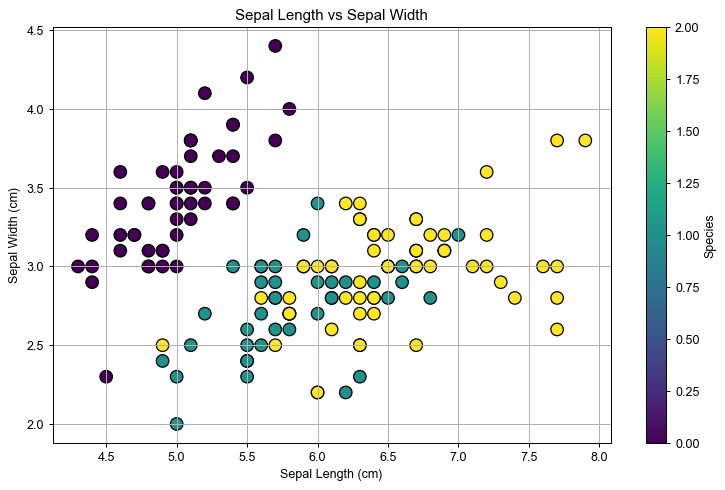

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(data['sepal length (cm)'], data['sepal width (cm)'], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

这张图展示了花萼长度与花萼宽度之间的关系，其中每个点的颜色代表不同的鸢尾花种类。可以看到，数据呈现出明显的聚类趋势，不同品种的鸢尾花在这两个特征的空间中有所区分。

![原文参考图，当前结果见代码输出](attachments/img_025.png)

#### 特征缩放

现在，我们将进行标准化和归一化处理，并查看其对数据分布的影响。

##### 标准化

标准化是将数据转化为均值为0，标准差为1的分布。在某些机器学习模型中，标准化能让数据集的特征更符合模型假设。

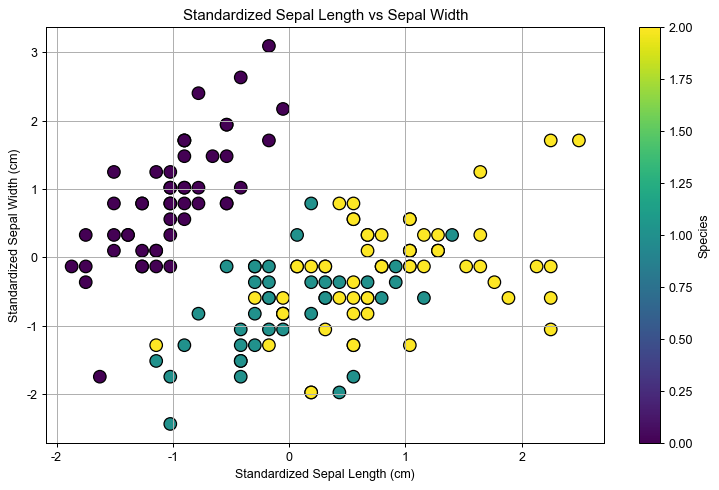

In [4]:
# 标准化处理
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# 标准化后的数据可视化
X_standardized_df = pd.DataFrame(X_standardized, columns=feature_names)
plt.figure(figsize=(10, 6))
plt.scatter(X_standardized_df['sepal length (cm)'], X_standardized_df['sepal width (cm)'], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Standardized Sepal Length vs Sepal Width')
plt.xlabel('Standardized Sepal Length (cm)')
plt.ylabel('Standardized Sepal Width (cm)')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_026.png)

##### 归一化

归一化是将数据按比例缩放到固定范围内，通常是 [0, 1]。归一化常用于距离计算比较敏感的算法，如KNN、SVM等。

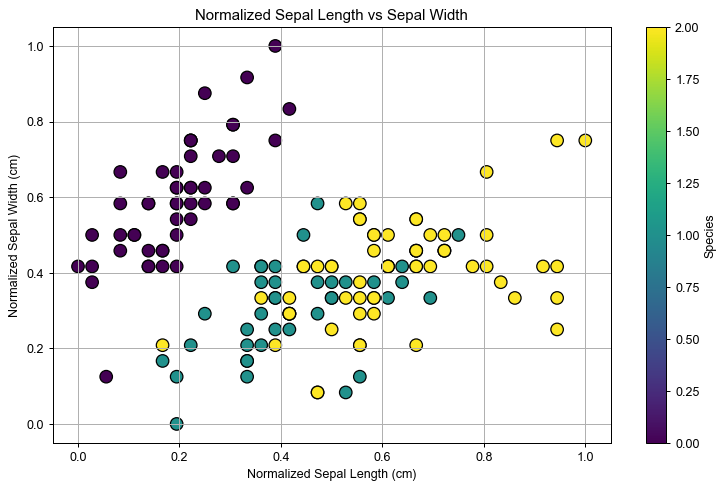

In [5]:
# 归一化处理
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)

# 归一化后的数据可视化
X_normalized_df = pd.DataFrame(X_normalized, columns=feature_names)
plt.figure(figsize=(10, 6))
plt.scatter(X_normalized_df['sepal length (cm)'], X_normalized_df['sepal width (cm)'], c=y, cmap='viridis', edgecolor='k', s=100)
plt.title('Normalized Sepal Length vs Sepal Width')
plt.xlabel('Normalized Sepal Length (cm)')
plt.ylabel('Normalized Sepal Width (cm)')
plt.colorbar(label='Species')
plt.grid(True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_027.png)

#### 模型训练与评估

标准化和归一化后的数据可以用于训练机器学习模型。我们选择了**随机森林分类器**来评估不同特征缩放方法对模型性能的影响。

##### 数据集划分

我们将数据集划分为训练集和测试集，其中80%的数据用于训练，20%的数据用于测试。

In [6]:
# 划分数据集，80%训练集，20%测试集
X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size=0.2, random_state=42)

# 训练随机森林模型
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 预测与评估
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy (Standardized): {accuracy:.4f}')

Accuracy (Standardized): 1.0000


##### 对比不同的特征缩放方法

我们还可以用归一化后的数据进行同样的训练与评估，来对比两种特征缩放方法的效果。

In [7]:
# 使用归一化后的数据进行训练与评估
X_train_normalized, X_test_normalized, y_train, y_test = train_test_split(X_normalized, y, test_size=0.2, random_state=42)

clf.fit(X_train_normalized, y_train)
y_pred_normalized = clf.predict(X_test_normalized)
accuracy_normalized = accuracy_score(y_test, y_pred_normalized)

print(f'Accuracy (Normalized): {accuracy_normalized:.4f}')

Accuracy (Normalized): 1.0000


通过以上分析与实验，我们可以得出以下几点结论：

1. **特征缩放的重要性**：对于一些基于距离的算法（如KNN、SVM等），特征缩放显得尤为重要。标准化和归一化两种方法能显著改善模型的训练效果和精度。
2. **对比不同的缩放方法**：在本示例中，标准化和归一化对随机森林的影响不大，因为随机森林对特征的尺度不敏感。然而，对于其他算法（如KNN和SVM），归一化和标准化将发挥更大作用。
3. **优化与调参**：通过调整算法的超参数（如树的数量、深度等），可以进一步提高模型的准确度。

总的来说，数据预处理和特征缩放在机器学习模型中起着至关重要的作用。通过合理选择特征缩放方法和进行算法优化，可以显著提升模型性能，特别是当数据的特征具有不同的量纲或数值范围时，特征缩放能够确保模型的稳定性和精度。

## 模型分析

### 优缺点分析

我们使用数据预处理中的特征缩放技术，特别是标准化（Standardization）和归一化（Normalization），来处理鸢尾花数据集，并使用了随机森林模型进行训练。对于特征缩放的优缺点，我们可以从以下几个角度进行分析：

#### 优点

1. **提高模型效率和准确性**：特征缩放在许多基于距离计算的模型（如KNN、SVM）中至关重要。它能够确保模型在训练时，所有特征对目标变量的影响更加平衡。即使对于像随机森林这样的树模型，特征缩放也能保证特征值范围的一致性，避免某些特征在训练中主导模型的决策过程。
2. **帮助算法更快收敛**：在一些优化算法中（如梯度下降法），特征缩放能够加速模型的收敛速度，尤其是在使用神经网络、逻辑回归等基于梯度优化的算法时，特征缩放可以有效减少训练时间，提高效率。
3. **避免数值溢出或梯度消失问题**：对于一些敏感的算法（如支持向量机、K-means等），数据如果没有进行特征缩放，特征值差异较大可能会导致数值溢出或梯度消失的问题。通过标准化或归一化，特征值统一范围，避免了此类问题。
4. **提高模型的泛化能力**：通过特征缩放，模型能够更好地识别各个特征之间的关系，避免模型过度依赖某些特征的巨大数值范围而降低泛化能力。它有助于减少过拟合现象，尤其是当数据集的特征之间存在较大差异时。

#### 缺点

1. **对某些算法效果不明显**：对于基于树的模型，如决策树、随机森林、XGBoost等，特征缩放通常不会对模型性能产生太大影响。这些算法本身并不依赖于特征的尺度，它们通过划分数据的不同特征来进行决策，因此特征的范围或分布对它们的训练影响较小。
2. **可能会损失数据的原始特征信息**：特征缩放虽然能加速模型训练和提高效果，但在某些情况下，缩放过程可能会导致原始数据的分布信息丢失。例如，在某些特征对预测结果有重要影响时，标准化或归一化可能会改变这些特征的本质属性。
3. **增加计算开销**：特征缩放需要计算每个特征的均值、标准差或最大值、最小值等统计量。这一过程对于数据集较大的情况下可能会增加计算的复杂度，尤其是在特征数量非常多时。
4. **对异常值敏感**：特征缩放，尤其是归一化，可能会受到异常值的影响。特别是最大值和最小值的变化较大的时候，异常值可能会极大地影响缩放后的数据分布，导致模型出现偏差。标准化的情况下，虽然均值和标准差对异常值的影响较小，但在某些极端情况下，仍然可能会影响模型的性能。

### 与相似算法的对比

在实际应用中，特征缩放可能与一些其他算法（如决策树、XGBoost、KNN、SVM等）结合使用，下面的表格对这些算法进行了对比，帮助理解何时采用特征缩放可能是优选，何时可能需要考虑其他算法。

| **算法** | **是否依赖特征缩放** | **优点** | **缺点** | **适用场景** |
|-|-|-|-|-|
| **随机森林** | 不依赖特征缩放 | 对特征缩放不敏感，能处理非线性问题，强大的特征选择能力，适应性强 | 模型训练时间较长，容易过拟合，尤其是在树的数量过多时 | 数据特征有非线性关系时，且对特征尺度不敏感，特别是多类分类任务 |
| **支持向量机** | 依赖特征缩放 | 适合高维空间，能处理复杂的非线性决策边界，具有较好的泛化能力 | 对参数和特征缩放敏感，训练时间长，尤其在数据量大时 | 特征维度高、数据线性不可分时，尤其适用于文本分类、图像分类等 |
| **K最近邻** | 依赖特征缩放 | 简单、直观，适用于小规模数据，能处理非线性问题 | 计算量大，尤其在数据量很大的时候，效果不稳定 | 当数据量较小且特征之间的关系复杂时，适用于分类、回归任务 |
| **决策树** | 不依赖特征缩放 | 可解释性强，模型容易理解，处理缺失数据能力强，适用于大数据 | 容易过拟合，尤其是在树深度过大时 | 特征之间无序列关系时，数据规模较大且决策过程需要解释时 |
| **XGBoost** | 不依赖特征缩放 | 强大的集成学习能力，适用于大规模数据，常用于解决复杂的分类任务 | 对参数调节敏感，训练时间长，计算复杂 | 大规模数据、复杂特征关系、非线性数据时，适用于分类与回归 |
| **线性回归** | 依赖特征缩放 | 模型简单，计算速度快，易于解释，适用于大规模数据 | 对异常值非常敏感，且无法处理复杂的非线性关系 | 特征之间线性关系较强时，尤其在预测任务中效果较好 |

### 何时选择使用特征缩放与其他处理方式

1. **优选情况**：

   - **数据量较小且特征差异较大时**：特征缩放能确保每个特征在训练过程中都能均衡地影响模型，避免某些特征因数值范围大而主导模型，特别是使用如KNN、SVM这类基于距离的模型时。
   - **使用神经网络或基于梯度优化的算法时**：神经网络、逻辑回归等梯度优化算法对特征缩放十分敏感，标准化或归一化能够加速训练过程，提高模型收敛速度。
   - **距离度量非常重要的任务**：例如KNN、SVM、聚类等任务，特征缩放能够保证模型对各个特征的权重更加均衡，从而提升效果。
2. **可以考虑其他算法**：

   - **特征之间的关系复杂且非线性时**：对于基于树的算法（如随机森林、XGBoost、决策树等），特征缩放的影响较小，甚至不需要进行特征缩放。在这些情况下，选择如XGBoost、随机森林等算法往往能得到不错的结果。
   - **数据中存在大量异常值时**：归一化尤其容易受到异常值的影响，因此在数据存在大量异常值的情况下，可能更适合使用决策树类模型，或者在使用标准化时，先对异常值进行处理。
   - **特征具有强线性关系时**：在线性回归等模型中，如果数据的特征间关系较为线性且不涉及复杂的非线性决策边界，特征缩放可能对结果影响不大，甚至可以跳过。

总结而言，特征缩放在许多基于距离计算的算法中是必不可少的，但对于树模型等不依赖距离计算的算法，特征缩放的效果则相对较小。在选择算法时，需要根据数据特征、任务要求以及算法本身的特性，合理选择是否进行特征缩放和选择合适的算法。